# MNIST Classification With Learned Superposition Activations

This notebook runs on the **full MNIST** split from sklearn/OpenML (~70k samples). The first run downloads MNIST and caches it locally.

Training uses **JAX + Optax** when available (`pip install "qfun[gpu]"`, then install a [CUDA-enabled jaxlib](https://jax.readthedocs.io/en/latest/installation.html) on Linux or Windows for GPU). The same code path runs on CPU if only the CPU jaxlib is installed. Without JAX, set `use_jax=False` in the config (PennyLane autograd over the full set can be very slow).

Features are **standardized** and compressed with **PCA** before baselines and quantum models.


In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan._classification_benchmarks import (
    build_comparison_rows,
    display_baseline_suite,
    display_quantum_result,
    print_comparison_table,
    print_split_summary,
    plot_training_diagnostics,
    run_default_baseline_suite,
    run_quantum_experiment,
)


## Config

Defaults mirror notebook 08. `use_jax=True` enables minibatch Adam on JAX (CPU or GPU). Without JAX installed, set `use_jax=False` (expect long runtimes on ~52k training points).


In [2]:
data_seed = 7
test_size = 0.25
pca_components = 32

hidden_units = 6
n_qubits = 3
steps = 60
learning_rate = 0.04
log_every = 5
snapshot_interval = 5
eval_shots = 3_000

try:
    import jax  # noqa: F401

    use_jax = True
except ImportError:
    use_jax = False
    print('Tip: pip install "qfun[gpu]" for JAX training on full MNIST (much faster).')

batch_size = 1024


## 1. Load, standardize, and compress MNIST

`load_classification_dataset("mnist")` may download once via sklearn/OpenML. We stratify the train/test split on labels, **standardize** 784-dimensional pixels, and apply **PCA** to `pca_components` dimensions before any model training.


In [3]:
mnist_dataset = load_classification_dataset("mnist")
mnist_split = prepare_classification_split(
    mnist_dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
    pca_components=pca_components,
)
class_names = mnist_split.target_names
print(f"Dataset size: {mnist_dataset.X.shape[0]} samples (full MNIST)")
print_split_summary(mnist_dataset.name, mnist_split)


Subset size: 1000 samples
Dataset: Mnist
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training set: 750 samples
Test set:     250 samples
Feature dimension: 32
Train class counts: [74 85 75 76 73 67 74 78 74 74]
Test class counts:  [25 28 25 26 24 23 24 26 24 25]
PCA components: 32


## 2. Baselines


LogisticRegression
  accuracy = 0.7680
  macro-F1 = 0.7621
              precision    recall  f1-score   support

           0      0.846     0.880     0.863        25
           1      0.929     0.929     0.929        28
           2      0.710     0.880     0.786        25
           3      0.818     0.692     0.750        26
           4      0.741     0.833     0.784        24
           5      0.667     0.609     0.636        23
           6      0.769     0.833     0.800        24
           7      0.741     0.769     0.755        26
           8      0.714     0.625     0.667        24
           9      0.714     0.600     0.652        25

    accuracy                          0.768       250
   macro avg      0.765     0.765     0.762       250
weighted avg      0.768     0.768     0.765       250

MLPClassifier
  accuracy = 0.8320
  macro-F1 = 0.8323
              precision    recall  f1-score   support

           0      0.852     0.920     0.885        25
           1      0

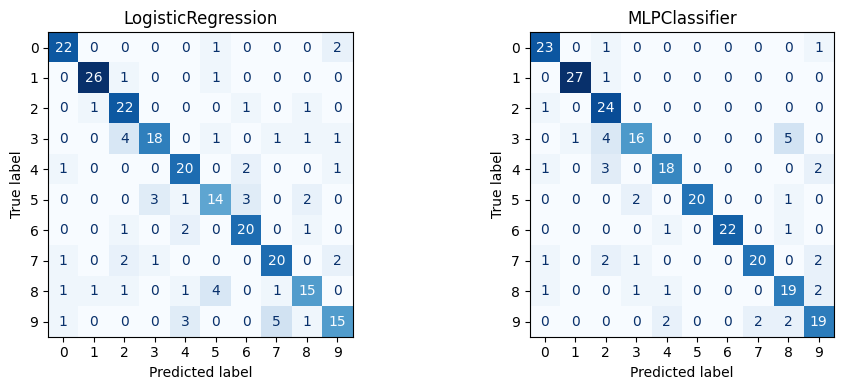

In [4]:
baseline_results = run_default_baseline_suite(
    mnist_split,
    seed=data_seed,
    mlp_hidden_layer_sizes=(64,),
)
display_baseline_suite(baseline_results, class_names)


## 3. Standard Superposition Activations


Training 60 epochs (logging every 5)…
  epoch 5/60  train_loss=2.148530
  epoch 10/60  train_loss=1.924615
  epoch 15/60  train_loss=1.764456
  epoch 20/60  train_loss=1.614477
  epoch 25/60  train_loss=1.509335
  epoch 30/60  train_loss=1.434086
  epoch 35/60  train_loss=1.369254
  epoch 40/60  train_loss=1.310787
  epoch 45/60  train_loss=1.252873
  epoch 50/60  train_loss=1.205661
  epoch 55/60  train_loss=1.178772
  epoch 60/60  train_loss=1.137836
MNIST standard superposition activations
  train accuracy = 0.6133
  test accuracy  = 0.4960
  macro-F1       = 0.4848
  tracked units  = [3, 1]
              precision    recall  f1-score   support

           0      0.577     0.600     0.588        25
           1      0.767     0.821     0.793        28
           2      0.375     0.480     0.421        25
           3      0.500     0.423     0.458        26
           4      0.333     0.292     0.311        24
           5      0.458     0.478     0.468        23
           6      0

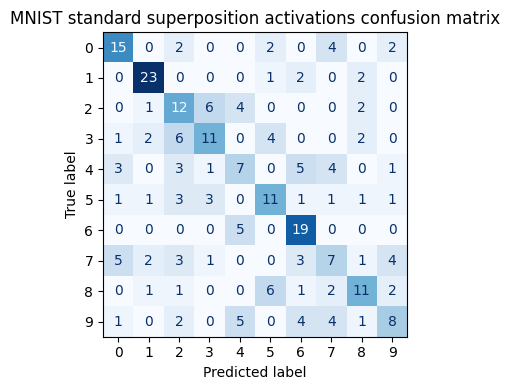

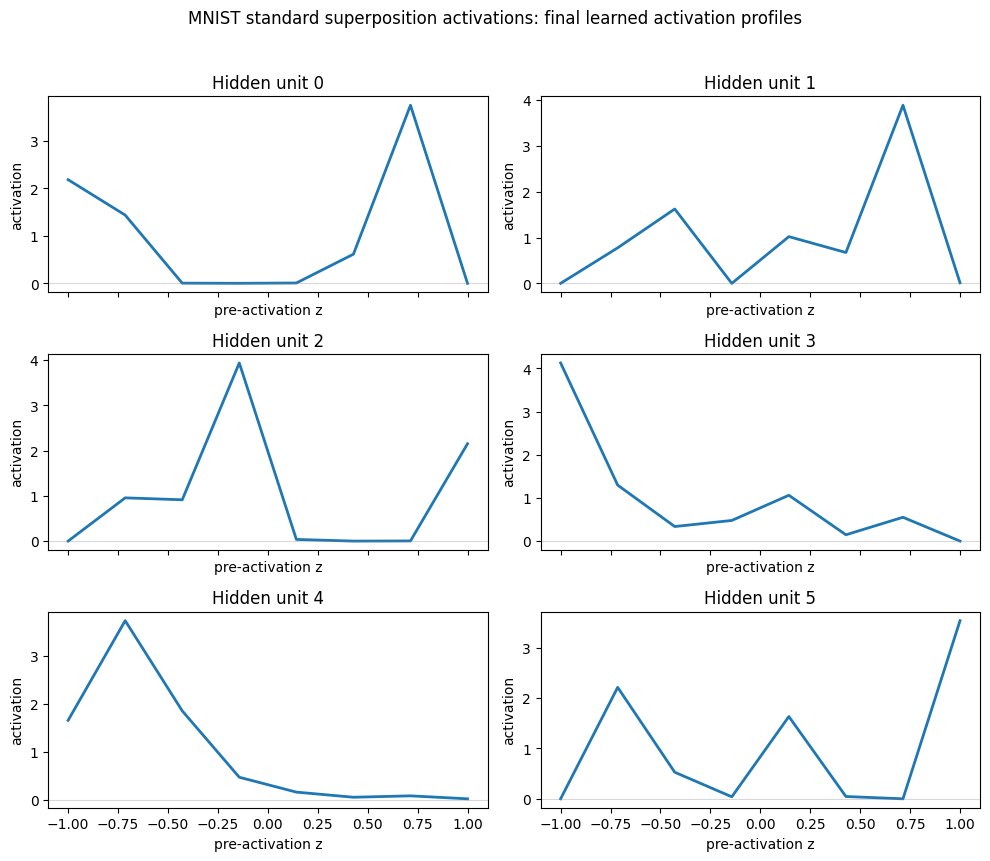

unit 3: exact-vs-measured L1 = 0.193057
unit 1: exact-vs-measured L1 = 0.246755


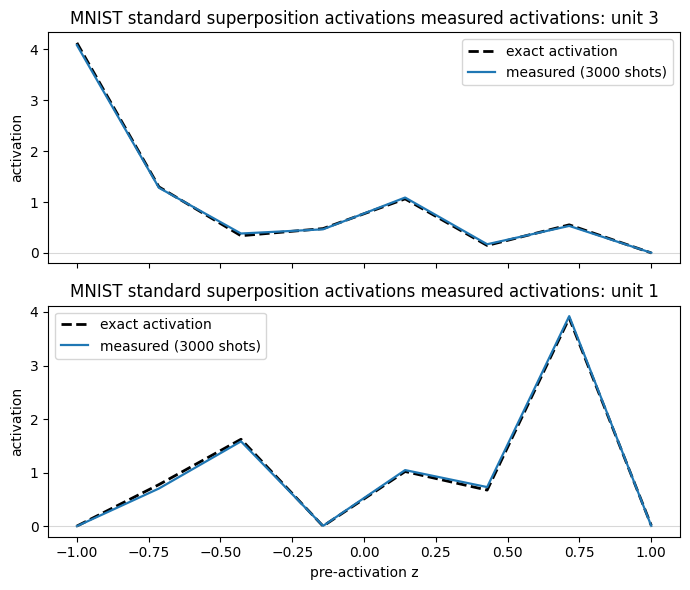

In [5]:
standard_result = run_quantum_experiment(
    "standard",
    label="MNIST standard superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
)
display_quantum_result(standard_result, class_names)


### Standard Training Process (Snapshots)


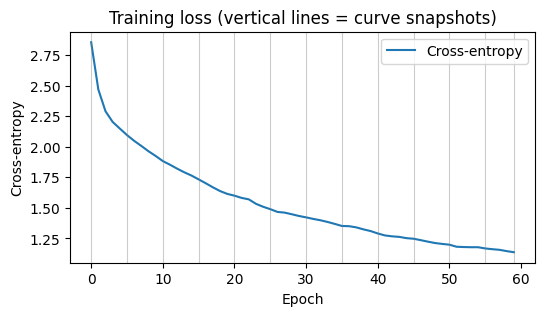

Epoch | loss at snapshot
   -1 | 2.85407
    6 | 2.04817
   13 | 1.79091
   20 | 1.59999
   27 | 1.46149
   34 | 1.36925
   41 | 1.27506
   48 | 1.21279
   55 | 1.16872


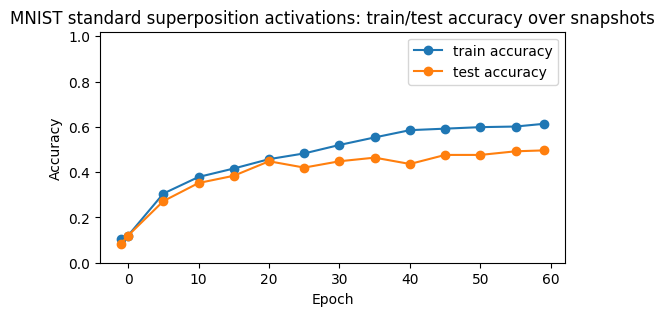

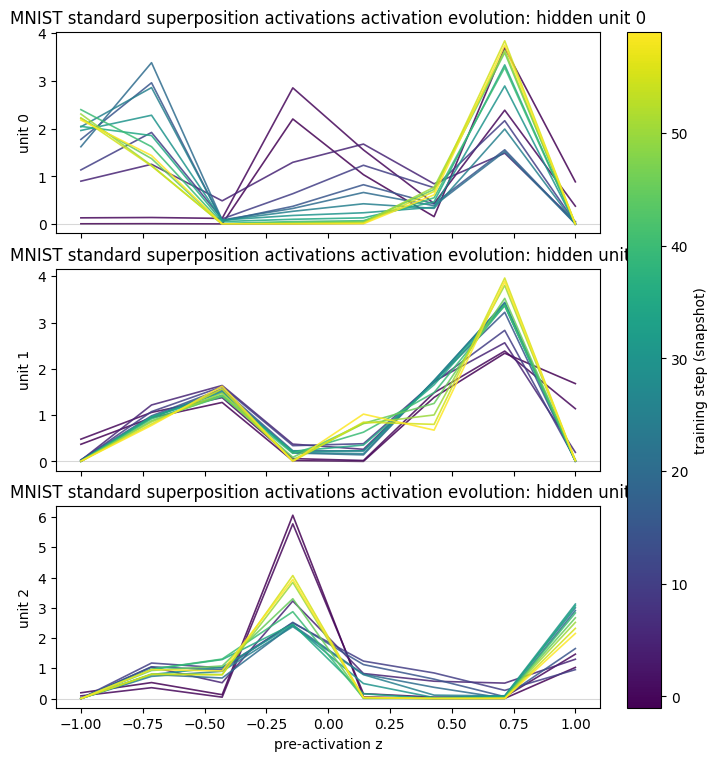

In [6]:
plot_training_diagnostics(standard_result)


## 4. Mode A Signed Superposition Activations


In [7]:
mode_a_result = run_quantum_experiment(
    "mode_a",
    label="MNIST Mode A superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
)
display_quantum_result(mode_a_result, class_names)


Training 60 epochs (logging every 5)…
  epoch 5/60  train_loss=2.073252


KeyboardInterrupt: 

### Mode A Training Process (Snapshots)


In [ ]:
plot_training_diagnostics(mode_a_result)


## 5. Mode B Signed Superposition Activations


In [ ]:
mode_b_result = run_quantum_experiment(
    "mode_b",
    label="MNIST Mode B superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
)
display_quantum_result(mode_b_result, class_names)


### Mode B Training Process (Snapshots)


In [ ]:
plot_training_diagnostics(mode_b_result)


## 6. Final Comparison


In [ ]:
comparison_rows = build_comparison_rows(
    baseline_results,
    [standard_result, mode_a_result, mode_b_result],
)
print_comparison_table(comparison_rows)
